In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/Users/nurilasalamat/Documents/ml/MoMA+Art+Collection/Artists.csv") #load dataset
#EDA
df["DisplayName"].nunique() #unique values in DisplayName

15581

In [ ]:
df #dataset preview

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
0,1,Robert Arneson,"American, 1930–1992",American,male,1930,1992,NaN,NaN
1,2,Doroteo Arnaiz,"Spanish, born 1936",Spanish,male,1936,0,NaN,NaN
2,3,Bill Arnold,"American, born 1941",American,male,1941,0,NaN,NaN
3,4,Charles Arnoldi,"American, born 1946",American,male,1946,0,Q1063584,500027998.0
4,5,Per Arnoldi,"Danish, born 1941",Danish,male,1941,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
15633,138522,Erwin Heerich,"German, 1922 – 2004",German,male,1922,2004,NaN,NaN
15634,138540,Rafael Rivera García,"Puerto Rican, 1929 – 2014",Puerto Rican,male,1929,2014,NaN,NaN
15635,138541,Rafael López del Campo,"Puerto Rican, 1936 – 2009",Puerto Rican,male,1936,2009,NaN,NaN
15636,138544,Efrain Lopez,"Puerto Rican, 1940 – 1993",Puerto Rican,male,1940,1993,NaN,NaN


In [ ]:
df.head() #first 5 rows

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
0,1,Robert Arneson,"American, 1930–1992",American,male,1930,1992,NaN,NaN
1,2,Doroteo Arnaiz,"Spanish, born 1936",Spanish,male,1936,0,NaN,NaN
2,3,Bill Arnold,"American, born 1941",American,male,1941,0,NaN,NaN
3,4,Charles Arnoldi,"American, born 1946",American,male,1946,0,Q1063584,500027998.0
4,5,Per Arnoldi,"Danish, born 1941",Danish,male,1941,0,NaN,NaN


In [ ]:
df.tail() #last 5 rows

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
15633,138522,Erwin Heerich,"German, 1922 – 2004",German,male,1922,2004,NaN,NaN
15634,138540,Rafael Rivera García,"Puerto Rican, 1929 – 2014",Puerto Rican,male,1929,2014,NaN,NaN
15635,138541,Rafael López del Campo,"Puerto Rican, 1936 – 2009",Puerto Rican,male,1936,2009,NaN,NaN
15636,138544,Efrain Lopez,"Puerto Rican, 1940 – 1993",Puerto Rican,male,1940,1993,NaN,NaN
15637,138567,Jonas Hafner,"German, born 1940",German,NaN,1940,0,NaN,NaN


In [ ]:
df.info() #data types, non-null columns counts

<class 'pandas.DataFrame'>
RangeIndex: 15638 entries, 0 to 15637
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ConstituentID  15638 non-null  int64  
 1   DisplayName    15638 non-null  str    
 2   ArtistBio      13438 non-null  str    
 3   Nationality    13142 non-null  str    
 4   Gender         12381 non-null  str    
 5   BeginDate      15638 non-null  int64  
 6   EndDate        15638 non-null  int64  
 7   Wiki QID       3247 non-null   str    
 8   ULAN           2931 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 1.1 MB


In [ ]:
df.dtypes #data types of each column

ConstituentID      int64
DisplayName          str
ArtistBio            str
Nationality          str
Gender               str
BeginDate          int64
EndDate            int64
Wiki QID             str
ULAN             float64
dtype: object

In [ ]:
df.loc[df["BeginDate"] > 1930, ["DisplayName", "ArtistBio", "Nationality"]] #artists who began their career after 1930

,DisplayName,ArtistBio,Nationality
1,Doroteo Arnaiz,"Spanish, born 1936",Spanish
2,Bill Arnold,"American, born 1941",American
3,Charles Arnoldi,"American, born 1946",American
4,Per Arnoldi,"Danish, born 1941",Danish
6,Bill Aron,"American, born 1941",American
...,...,...,...
15624,MTA (Marina Tabassum Architects),"Bangladesh, founded 2005",Bangladeshi
15625,Johanna Unzueta,"Chilean, born 1974 Santiago, Chile. Lives and ...",Chilean
15635,Rafael López del Campo,"Puerto Rican, 1936 – 2009",Puerto Rican
15636,Efrain Lopez,"Puerto Rican, 1940 – 1993",Puerto Rican


In [ ]:
df.sort_values("EndDate", ascending = False).head(10) #artists who ended their careeer most recently

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
4095,4587,Richard Pettibone,"American, 1938-2024",American,male,1938,2024,NaN,NaN
4972,5569,Daniel Spoerri,"Swiss, born Romania. 1930–2024",Swiss,male,1930,2024,Q123487,500031201.0
207,240,Frank Auerbach,"British, born Germany. 1931 – 2024",British,male,1931,2024,Q215919,500023601.0
4576,5134,Lucas Samaras,"American, born Greece. 1936–2024",American,male,1936,2024,Q663175,500021682.0
4223,4728,David Prentice,"American, 1943–2024",American,male,1943,2024,NaN,NaN
741,833,Günter Brus,"Austrian, 1938–2024",Austrian,male,1938,2024,Q677218,500098254.0
3878,4347,Guillermo Núñez,"Chilean, 1930 – 2024",Chilean,male,1930,2024,NaN,NaN
5037,5640,Frank Stella,"American, 1936–2024",American,male,1936,2024,Q375268,500020533.0
1494,1696,Hans Eichenberger,"Swiss, 1926 - 2024",Swiss,male,1926,2024,NaN,NaN
6398,7154,Yong Soon Min,"American, born Korea. 1953–2024",American,female,1953,2024,NaN,NaN


In [ ]:
df.isnull().sum() #num of missing values per column

ConstituentID        0
DisplayName          0
ArtistBio         2200
Nationality       2496
Gender            3257
BeginDate            0
EndDate              0
Wiki QID         12391
ULAN             12707
dtype: int64

In [ ]:

df.dropna(how="all") #drop rows where all values are missing

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
0,1,Robert Arneson,"American, 1930–1992",American,male,1930,1992,NaN,NaN
1,2,Doroteo Arnaiz,"Spanish, born 1936",Spanish,male,1936,0,NaN,NaN
2,3,Bill Arnold,"American, born 1941",American,male,1941,0,NaN,NaN
3,4,Charles Arnoldi,"American, born 1946",American,male,1946,0,Q1063584,500027998.0
4,5,Per Arnoldi,"Danish, born 1941",Danish,male,1941,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
15633,138522,Erwin Heerich,"German, 1922 – 2004",German,male,1922,2004,NaN,NaN
15634,138540,Rafael Rivera García,"Puerto Rican, 1929 – 2014",Puerto Rican,male,1929,2014,NaN,NaN
15635,138541,Rafael López del Campo,"Puerto Rican, 1936 – 2009",Puerto Rican,male,1936,2009,NaN,NaN
15636,138544,Efrain Lopez,"Puerto Rican, 1940 – 1993",Puerto Rican,male,1940,1993,NaN,NaN


In [ ]:
df.shape #num of rows and columns



(15638, 9)

In [ ]:
df.columns #list of column names

Index(['ConstituentID', 'DisplayName', 'ArtistBio', 'Nationality', 'Gender',
       'BeginDate', 'EndDate', 'Wiki QID', 'ULAN'],
      dtype='str')

In [ ]:
df["ULAN"].unique() #unique values in ULAN column

array([           nan, 5.00027998e+08, 5.00003363e+08, ...,
       5.00088180e+08, 5.00015324e+08, 5.00118451e+08], shape=(2929,))

In [ ]:
df.describe() #summary

,ConstituentID,BeginDate,EndDate,ULAN
count,15638.000000,15638.000000,15638.000000,2.931000e+03
mean,24120.605960,1491.669843,709.111587,5.000744e+08
std,29489.630661,810.180276,949.239575,8.660346e+04
min,1.000000,0.000000,0.000000,5.000000e+08
25%,4381.250000,1855.250000,0.000000,5.000176e+08
50%,9498.500000,1923.000000,0.000000,5.000330e+08
75%,35560.250000,1948.000000,1968.000000,5.001146e+08
max,138567.000000,2017.000000,2024.000000,5.003566e+08


In [ ]:
df.describe(include="object") #summary for categorical columns

/var/folders/cj/pyg3106x49q_d54nbw4ww5k80000gn/T/ipykernel_1002/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,DisplayName,ArtistBio,Nationality,Gender,Wiki QID
count,15638,13438,13142,12381,3247
unique,15581,7720,131,6,3242
top,Unidentified Designer,American,American,male,Q1524052
freq,22,355,5305,9940,2


In [ ]:
df["Nationality"].describe() #summary for Nationality column

count        13142
unique         131
top       American
freq          5305
Name: Nationality, dtype: object

In [ ]:
df["Nationality"].value_counts().head(10) #top 10 nationalities among artists

Nationality
American    5305
German       984
British      872
French       864
Italian      539
Japanese     510
Swiss        298
Dutch        282
Russian      261
Austrian     242
Name: count, dtype: int64

In [ ]:
df[df["BeginDate"] > df["EndDate"]] #data quality issue: BeginDate later than EndDate

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
1,2,Doroteo Arnaiz,"Spanish, born 1936",Spanish,male,1936,0,NaN,NaN
2,3,Bill Arnold,"American, born 1941",American,male,1941,0,NaN,NaN
3,4,Charles Arnoldi,"American, born 1946",American,male,1946,0,Q1063584,500027998.0
4,5,Per Arnoldi,"Danish, born 1941",Danish,male,1941,0,NaN,NaN
5,6,Danilo Aroldi,"Italian, born 1925",Italian,male,1925,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
15617,138280,Teresita Brigitte Cochran,"American, born 1975",American,female,1975,0,NaN,NaN
15618,138316,"Carlos ""Chino"" García","American, born Puerto Rico, 1947",American,male,1947,0,NaN,NaN
15624,138323,MTA (Marina Tabassum Architects),"Bangladesh, founded 2005",Bangladeshi,NaN,2005,0,NaN,NaN
15625,138366,Johanna Unzueta,"Chilean, born 1974 Santiago, Chile. Lives and ...",Chilean,female,1974,0,NaN,NaN


In [ ]:
df.groupby("Nationality")["BeginDate"].mean().sort_values(ascending=False).head(20) #nationalities with highes† avg begin date

Nationality
Caribbean         2011.000000
Nepali            1988.000000
Kenyan            1985.600000
Sahrawi           1979.000000
Kyrgyz            1978.500000
Afghan            1973.000000
Bahamian          1971.500000
Oneida            1971.000000
Singaporean       1970.666667
Sierra Leonean    1970.000000
Albanian          1969.000000
Ugandan           1968.000000
Cypriot           1967.000000
Salvadoran        1966.500000
Taiwanese         1966.400000
Malaysian         1966.333333
New Zealander     1965.750000
Indonesian        1965.000000
Cameroonian       1964.500000
Filipino          1964.000000
Name: BeginDate, dtype: float64

In [ ]:
df.isnull().mean().sort_values(ascending=False)  #percentage of missing values per column

ULAN             0.812572
Wiki QID         0.792365
Gender           0.208275
Nationality      0.159611
ArtistBio        0.140683
ConstituentID    0.000000
DisplayName      0.000000
BeginDate        0.000000
EndDate          0.000000
dtype: float64

In [ ]:
df.duplicated().sum() #num of duplicate rows

np.int64(0)

<Axes: xlabel='BeginDate', ylabel='Count'>

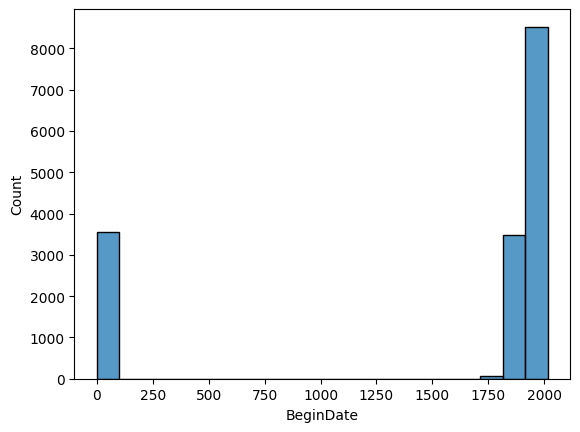

In [ ]:
#Visualizations

sns.histplot(df["BeginDate"], bins=20) #histogram shows the distribution of artists' begin date

<Axes: xlabel='BeginDate'>

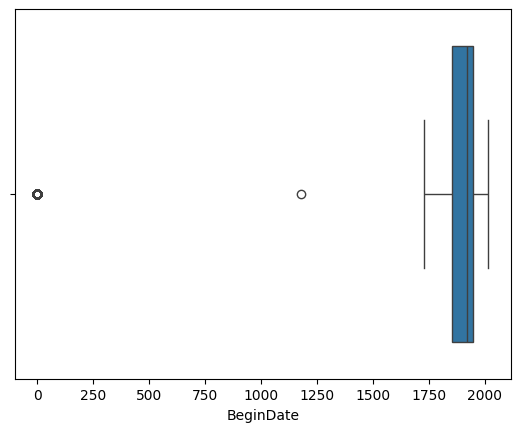

In [ ]:
sns.boxplot(x=df["BeginDate"]) #shows outliers in begin date

<Axes: xlabel='count', ylabel='Nationality'>

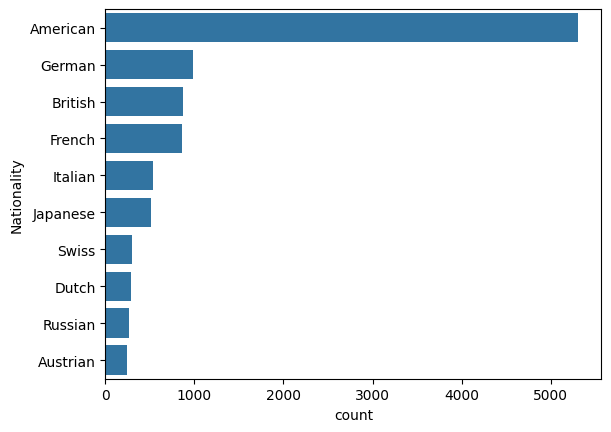

In [ ]:
top_nationalities = df["Nationality"].value_counts().head(10)
top_df = df[df["Nationality"].isin(top_nationalities.index)]

sns.countplot(y="Nationality", data=top_df, order=top_nationalities.index)
#plot shows the frequency distribution of top nationalities among artists

<Axes: xlabel='Nationality', ylabel='BeginDate'>

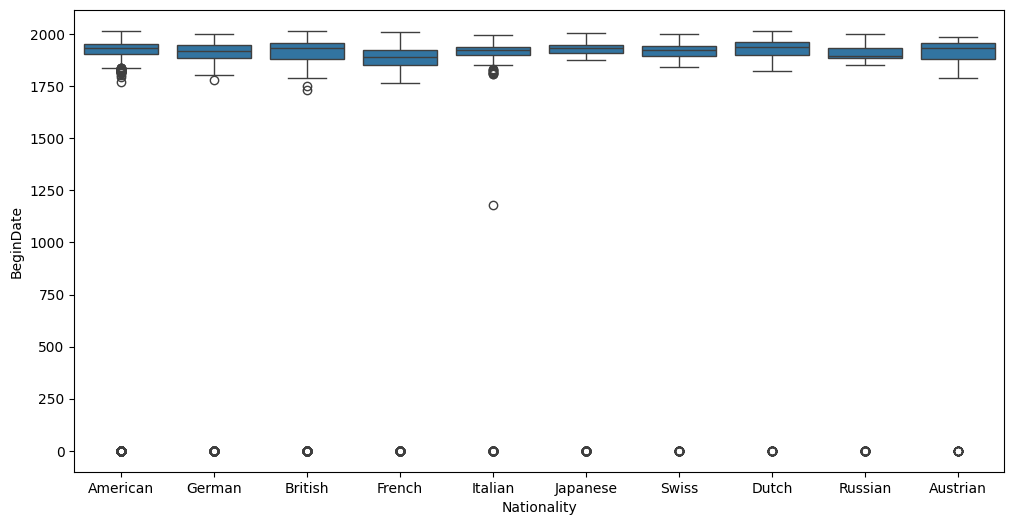

In [ ]:
top_nationalities = df["Nationality"].value_counts().head(10)
top_df = df[df["Nationality"].isin(top_nationalities.index)]
plt.figure(figsize=(12,6))
sns.boxplot(x="Nationality", y="BeginDate", data=top_df, order=top_nationalities.index) 
plt.show()
#comparing begin date among nationalities

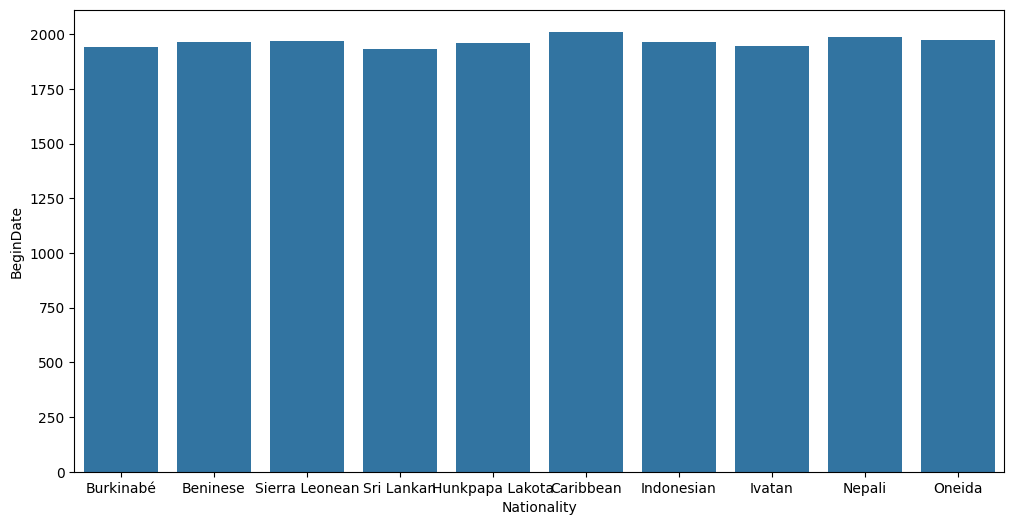

In [45]:
bottom_nationalities = df["Nationality"].value_counts().tail(10)
top_df = df[df["Nationality"].isin(bottom_nationalities.index)]
plt.figure(figsize=(12,6))
sns.barplot(x="Nationality", y="BeginDate", data=top_df, order=bottom_nationalities.index) #avg begin date for bottom count nationality
plt.show()

<Axes: xlabel='BeginDate', ylabel='EndDate'>

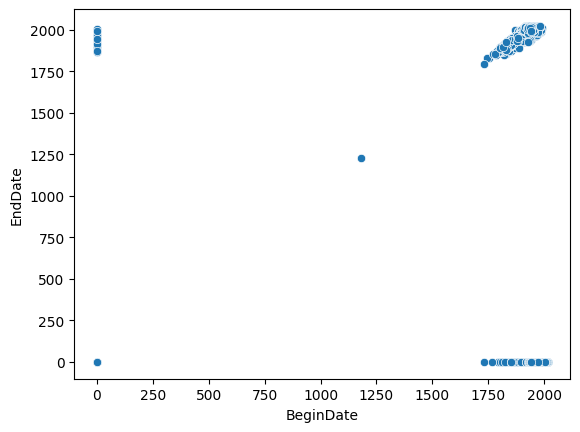

In [33]:
sns.scatterplot(x="BeginDate", y="EndDate", data=df)
#relationship between begin da†e and end date

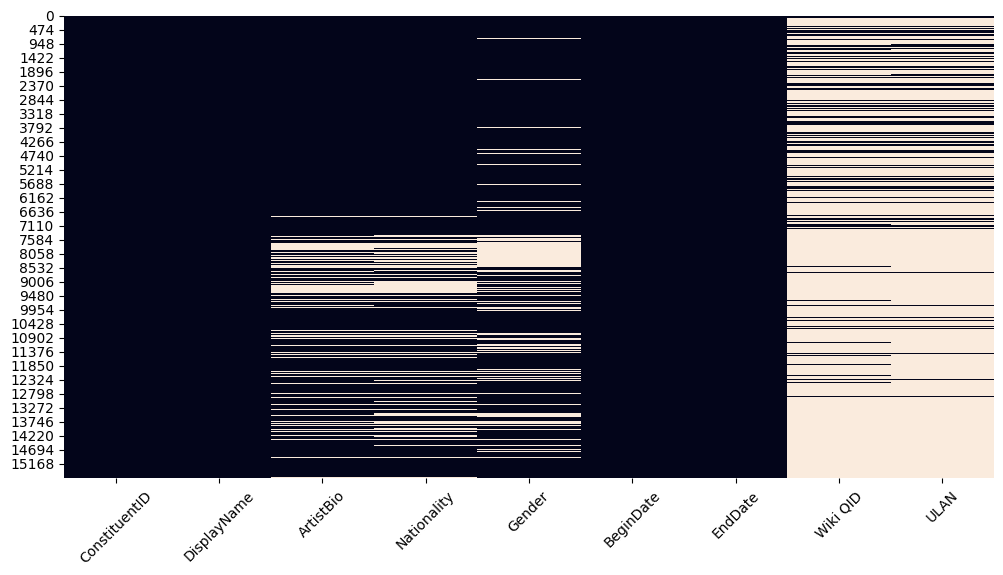

In [44]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.xticks(rotation=45)
plt.show()
#visualizing missing values